> **Runtime: Colab only.** This notebook needs `transformers` + `torch`, which do not run under JupyterLite (no Rust/C extensions in Pyodide). On Colab the install is fast and the model is ~330 MB.
>
> [![Open in Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/L3GJ0N/course-notebooks-public/blob/main/01-attention-distilgpt2.ipynb)
>
> **[Click here to open in Google Colab](https://colab.research.google.com/github/L3GJ0N/course-notebooks-public/blob/main/01-attention-distilgpt2.ipynb)**

# From NumPy Attention to Real distilgpt2

**Lecture 5 — Inside the Transformer**

This notebook is self-contained. You build attention from scratch in NumPy, then apply the same code to a real transformer:

- **Part 1 — Build the reusable primitives in NumPy.** You implement scaled dot-product `attention(Q, K, V)` straight from the lecture formula — in small, separately-tested pieces (scaled scores → causal mask → the assembled function) — then stack single-head calls into `multi_head_attention()`. A `show_attention_scores()` plot helper is given. Short NumPy warm-ups come first; we test everything on a small dragon-drinks toy.
- **Part 2 — Apply to real distilgpt2.** Reuse the same primitives to reproduce the attention sub-layer of layer 3 of `distilgpt2` against HuggingFace, visualise all 12 heads, and sample next-token candidates.

By the end you will have one set of small, tested functions that scales from a 3-token toy to a real 82M-parameter language model — without rewriting the math in between.

## 1. Setup

Colab pre-installs `torch`. We add `transformers`. Loading `distilgpt2` later takes 5–15 seconds; weights are cached after the first load.

In [1]:
%pip install -q transformers

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from transformers import GPT2LMHeadModel, GPT2TokenizerFast

rng = np.random.default_rng(42)
print('NumPy', np.__version__)

NumPy 2.0.2


## Part 1 — Build the reusable primitives

Two families of primitives feed into the rest of the notebook:

**Sampling utilities** — softmax and the three knobs that control how we pick from a probability distribution (temperature, top-k, top-p / nucleus). We'll need these twice: implicitly inside attention (every attention row is a softmax), and explicitly at the end when we sample next tokens from distilgpt2.

**Attention primitives** — scaled dot-product `attention(Q, K, V)` built in three small pieces (`scaled_scores`, `build_causal_mask`, then the assembled function), a reusable `show_attention_scores()` plotter (given), and `multi_head_attention()` as a loop over single-head `attention()` calls.

You implement each one, test it on small examples, then put them all together on `distilgpt2` in Part 2.

Before any of that, a short primer (**section 1.1**) on NumPy's `axis=` argument and the row-major convention this notebook uses — followed by three hands-on warm-ups for the exact NumPy operations (slicing, `@`/`.T`, `np.concatenate`) the later exercises lean on. The whole rest of Part 1 depends on being comfortable with "the last axis is the per-token feature axis", so don't skip it.

### 1.1 NumPy axes and row-wise thinking

If you arrived at NumPy after Python lists, your instinct is probably to picture an array as a nested list and walk it with `for` loops. NumPy *lets* you do that — but the rest of this notebook assumes you read the vectorised form, where one line replaces a double loop. Two ideas make the leap painless: **row-major layout** and **axis arguments**.

**Row-major layout** (the lecture's "row-wise notation"). We store sequences with **one row per token** and one column per feature. For `T` tokens and embedding dimension `d`, the input matrix has shape `(T, d)`:

```
            feat 0   feat 1   feat 2   ...   feat d-1
token 0     x00      x01      x02      ...   x0(d-1)
token 1     x10      x11      x12      ...   x1(d-1)
...
token T-1   x(T-1)0  ...                     x(T-1)(d-1)
```

This convention runs through everything: `X` has shape `(T, d)`, `Q = X @ W_Q` is `(T, d_k)`, attention scores `S = Q @ K.T` are `(T, T)`, and so on. **Per-token operations always reduce along the last axis.**

**Axis: which dimension gets reduced.** Every NumPy reduction (`.sum`, `.mean`, `.max`, `.argmax`, `softmax`, ...) takes an `axis=` argument. The rule is short:

> `axis=k` means **collapse** dimension `k`, leave the others. The output rank drops by one — unless you pass `keepdims=True`.

For a 2-D `(T, d)` array:

| axis | what it does | output shape |
|---|---|---|
| `0` | reduce over rows (down each column) | `(d,)` — one value per feature |
| `1` | reduce over columns (across each row) | `(T,)` — one value per token |
| `-1` | "the last axis" (here same as `1`) | `(T,)` |

**Why we write `axis=-1` instead of `axis=1`.** It keeps working when the array grows an extra dimension. The same code that runs on `(T, d)` also runs on `(n_head, T, d)` because `-1` always points to the last axis. The per-token feature dimension is always last in our layout, so `axis=-1` is the right call for any per-token reduction.

**`keepdims=True`** keeps the reduced axis as size 1 instead of dropping it. We use it whenever the result must broadcast back against the original `(T, d)` array — for example, subtracting the per-row mean from each row of `X`. Without `keepdims`, the result has shape `(T,)`, which broadcasts the *wrong* way; with `keepdims=True` it has shape `(T, 1)`, which broadcasts correctly across the `d` columns.

In [3]:
# Worked example — make the axes concrete on a 3x4 array
X_demo = np.array([
    [1.0, 2.0, 3.0, 4.0],     # token 0
    [10.0, 20.0, 30.0, 40.0], # token 1
    [100.0, 200.0, 300.0, 400.0],  # token 2
])
print(f'X_demo shape: {X_demo.shape}  (T=3 tokens, d=4 features)\n')

# axis=0 — reduce over rows (down each column). One number per feature.
print(f'X_demo.sum(axis=0)      → {X_demo.sum(axis=0)}            shape {X_demo.sum(axis=0).shape}')
print(f'X_demo.mean(axis=0)     → {X_demo.mean(axis=0)}            shape {X_demo.mean(axis=0).shape}\n')

# axis=-1 (== axis=1 here) — reduce over the last axis. One number per token.
print(f'X_demo.sum(axis=-1)     → {X_demo.sum(axis=-1)}      shape {X_demo.sum(axis=-1).shape}')
print(f'X_demo.mean(axis=-1)    → {X_demo.mean(axis=-1)}     shape {X_demo.mean(axis=-1).shape}')
print(f'X_demo.argmax(axis=-1)  → {X_demo.argmax(axis=-1)}            shape {X_demo.argmax(axis=-1).shape}\n')

# keepdims=True: keep the reduced axis as size 1 so it broadcasts back
row_mean = X_demo.mean(axis=-1, keepdims=True)
print(f'X_demo.mean(axis=-1, keepdims=True) shape {row_mean.shape}:')
print(row_mean)
print(f'\nbroadcasting check: X_demo - row_mean shape {(X_demo - row_mean).shape}')
print('  → each row is centred at 0 (per-token mean removed):')
print((X_demo - row_mean))

X_demo shape: (3, 4)  (T=3 tokens, d=4 features)

X_demo.sum(axis=0)      → [111. 222. 333. 444.]            shape (4,)
X_demo.mean(axis=0)     → [ 37.  74. 111. 148.]            shape (4,)

X_demo.sum(axis=-1)     → [  10.  100. 1000.]      shape (3,)
X_demo.mean(axis=-1)    → [  2.5  25.  250. ]     shape (3,)
X_demo.argmax(axis=-1)  → [3 3 3]            shape (3,)

X_demo.mean(axis=-1, keepdims=True) shape (3, 1):
[[  2.5]
 [ 25. ]
 [250. ]]

broadcasting check: X_demo - row_mean shape (3, 4)
  → each row is centred at 0 (per-token mean removed):
[[  -1.5   -0.5    0.5    1.5]
 [ -15.    -5.     5.    15. ]
 [-150.   -50.    50.   150. ]]


### For-loop vs vectorised — same answer, very different code

A first-timer's row-wise softmax usually looks like this:

```python
def softmax_with_loops(X):
    out = np.zeros_like(X)
    for i in range(X.shape[0]):              # for each row...
        for j in range(X.shape[1]):
            out[i, j] = np.exp(X[i, j])      # ...exponentiate each entry
        out[i] /= out[i].sum()                # ...divide by the row sum
    return out
```

It's correct, but it runs every multiplication and exponentiation in **Python**, one element at a time. NumPy's `axis=-1` does the same thing in **compiled C**, vectorised across all entries simultaneously:

```python
def softmax_fast(X):
    e = np.exp(X)                              # element-wise, no axis argument needed
    return e / e.sum(axis=-1, keepdims=True)   # divide each row by its sum
```

Same math, no Python-level loops, easily 100× faster on real arrays. **For the rest of this notebook, default to the vectorised form.** Every reduction you'll see — softmax per row, LayerNorm per row, attention scores per query — has the same shape: `axis=-1` with `keepdims=True` when broadcasting requires it.

*(Note: this is the textbook softmax formula. In section 1.2 we'll add one small tweak — subtracting the row max before `exp` — to keep it from overflowing on large inputs. That's a numerical-stability concern, not an axis concern, so we leave it for the next section.)*

The cell below verifies both implementations agree, and gives you a feel for the speed gap.

In [4]:
# Two implementations of row-wise softmax — same math (the textbook formula),
# different code. Only the axis/vectorisation differs.
import time

def softmax_with_loops(X):
    out = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            out[i, j] = np.exp(X[i, j])
        out[i] /= out[i].sum()
    return out

def softmax_fast(X):
    e = np.exp(X)
    return e / e.sum(axis=-1, keepdims=True)

# Agreement: both should give the same numbers
X_small = np.array([[1.0, 2.0, 3.0],
                    [0.0, 0.0, 0.0],
                    [-1.0, 1.0, 5.0]])
slow = softmax_with_loops(X_small)
fast = softmax_fast(X_small)
print(f'rows of slow sum to: {slow.sum(axis=-1).round(6)}')
print(f'rows of fast sum to: {fast.sum(axis=-1).round(6)}')
print(f'max |slow - fast| = {np.max(np.abs(slow - fast)):.2e}\n')
assert np.allclose(slow, fast)

# Speed: how much does vectorisation actually buy us?
X_big = np.random.default_rng(0).normal(size=(200, 200))   # 200 tokens × 200 features

t0 = time.perf_counter(); _ = softmax_with_loops(X_big); t_slow = time.perf_counter() - t0
t0 = time.perf_counter(); _ = softmax_fast(X_big);       t_fast = time.perf_counter() - t0
print(f'softmax_with_loops on (200, 200): {t_slow*1000:7.2f} ms')
print(f'softmax_fast       on (200, 200): {t_fast*1000:7.2f} ms')
print(f'speedup: {t_slow / t_fast:.0f}×')

rows of slow sum to: [1. 1. 1.]
rows of fast sum to: [1. 1. 1.]
max |slow - fast| = 0.00e+00

softmax_with_loops on (200, 200):   68.00 ms
softmax_fast       on (200, 200):    0.68 ms
speedup: 100×


**Higher-rank arrays follow the same rule.** In Part 2, multi-head attention weights have shape `(n_head, T, T)` — three axes instead of two. To softmax across *each query's row of keys, for every head*, we still write `softmax(scores, axis=-1)`. The function doesn't care that there's an extra head dimension in front; `axis=-1` is still the per-query reduction.

That's the whole point of `axis=-1`: write the code once, and it works whether the data is `(T, d)`, `(n_head, T, T)`, or `(batch, n_head, T, T)`.

With axes understood, three quick NumPy warm-ups will arm you with the exact moves the attention exercises need.

### Three quick warm-ups before we build

The attention code ahead leans on three NumPy moves, over and over. Practise each one now on a tiny array, so the real exercises are about the *math*, not the *syntax*:

1. **Slicing** a 2-D array by rows, columns, and column *ranges* — how we split a packed `(T, 3d)` tensor into Q, K, V, and how each attention head grabs its own columns.
2. **Matrix-multiply with a transpose** (`A @ B.T`) — the all-pairs dot product that becomes the attention score matrix.
3. **Concatenating** arrays along the last axis — how multi-head attention glues its per-head outputs back together.

Each warm-up has a stub to fill in and a test cell right after. Fill the stub, run the test, move on.

**Your turn (1/3 — slicing):** Return four slices of a 2-D array. The third one, a *column range* (`arr[:, 1:3]`), is the move that powers `split_qkv` and the per-head split later — get comfortable with it here.

In [5]:
def slice_practice(arr):
    """Return four slices of a 2-D array `arr` (shape (R, C) with R>=3, C>=4).

    Returns a tuple (first_row, last_col, mid_cols, block):
        first_row : row 0                       -> shape (C,)
        last_col  : the last column             -> shape (R,)
        mid_cols  : columns 1 and 2 (a range)   -> shape (R, 2)
        block     : the top-left 2x2 block      -> shape (2, 2)

    Example:
        >>> a = np.arange(12).reshape(3, 4)
        >>> fr, lc, mc, bl = slice_practice(a)
        >>> fr.tolist()
        [0, 1, 2, 3]
        >>> lc.tolist()
        [3, 7, 11]
        >>> mc.tolist()
        [[1, 2], [5, 6], [9, 10]]
        >>> bl.tolist()
        [[0, 1], [4, 5]]
    """
    # TODO: return arr[0], arr[:, -1], arr[:, 1:3], arr[:2, :2]
    return (arr[0], arr[:, -1], arr[:, 1:3], arr[:2, :2])

In [6]:
# --- TEST: slice_practice ---
a = np.arange(12).reshape(3, 4)
fr, lc, mc, bl = slice_practice(a)
assert fr.tolist() == [0, 1, 2, 3], f'first_row wrong: {fr.tolist()}'
assert lc.tolist() == [3, 7, 11], f'last_col wrong: {lc.tolist()}'
assert mc.tolist() == [[1, 2], [5, 6], [9, 10]], f'mid_cols wrong: {mc.tolist()}'
assert bl.tolist() == [[0, 1], [4, 5]], f'block wrong: {bl.tolist()}'

print('slice_practice verified.')
print('Column ranges like arr[:, 1:3] are exactly how split_qkv and head_slice carve a tensor into pieces.')

slice_practice verified.
Column ranges like arr[:, 1:3] are exactly how split_qkv and head_slice carve a tensor into pieces.


**Your turn (2/3 — matmul + transpose):** Build the `(T, T)` matrix of all pairwise dot products between the rows of `Q` and `K`. One matrix product does it: `Q @ K.T`. The transpose is what makes the inner dimensions line up: `(T, d_k) @ (d_k, T) → (T, T)`.

In [11]:
def scores_practice(Q, K):
    """All-pairs dot products between rows of Q and rows of K.

    Q and K both have shape (T, d_k) — one row per token. Entry (i, j) of the
    result is the dot product of Q-row i with K-row j. The whole matrix is a
    single product Q @ K.T (note the transpose so the inner dims match).

    Args:
        Q, K: (T, d_k) arrays.

    Returns:
        (T, T) array; entry (i, j) is Q[i] . K[j].

    Example:
        >>> Q = np.array([[1.0, 0.0], [0.0, 1.0]])
        >>> K = np.array([[1.0, 2.0], [3.0, 4.0]])
        >>> scores_practice(Q, K).tolist()
        [[1.0, 3.0], [2.0, 4.0]]
    """
    # TODO: return Q @ K.T
    return Q@K.T

In [12]:
# --- TEST: scores_practice ---
Q_p = np.array([[1.0, 0.0], [0.0, 1.0]])
K_p = np.array([[1.0, 2.0], [3.0, 4.0]])
S_p = scores_practice(Q_p, K_p)
assert S_p.shape == (2, 2), f'shape wrong: {S_p.shape}'
assert S_p.tolist() == [[1.0, 3.0], [2.0, 4.0]], f'values wrong: {S_p.tolist()}'

# Non-square features: 3 tokens, 4 features -> still (3, 3) scores
rng_w = np.random.default_rng(7)
Qb, Kb = rng_w.normal(size=(3, 4)), rng_w.normal(size=(3, 4))
assert scores_practice(Qb, Kb).shape == (3, 3)

# Same answer as an explicit double loop over dot products
brute = np.array([[Qb[i] @ Kb[j] for j in range(3)] for i in range(3)])
assert np.allclose(scores_practice(Qb, Kb), brute)

print('scores_practice verified.')
print('This Q @ K.T is the heart of the attention score matrix you build in section 1.7.')

scores_practice verified.
This Q @ K.T is the heart of the attention score matrix you build in section 1.7.


**Your turn (3/3 — concatenate):** Glue a list of `(T, d_head)` blocks side by side into one `(T, n*d_head)` array along the last axis. This is the final step of multi-head attention: each head returns a slice, and we lay them next to each other to rebuild the full width.

In [13]:
def concat_practice(blocks):
    """Concatenate a list of (T, d_head) arrays side by side into one (T, n*d_head) array.

    Multi-head attention produces one (T, d_head) slice per head; we lay them
    next to each other along the last axis (axis=-1) to rebuild a full (T, d).

    Args:
        blocks: list of arrays, each shape (T, d_head).

    Returns:
        (T, len(blocks) * d_head) array.

    Example:
        >>> a = np.array([[1, 2], [3, 4]])
        >>> b = np.array([[5, 6], [7, 8]])
        >>> concat_practice([a, b]).tolist()
        [[1, 2, 5, 6], [3, 4, 7, 8]]
    """
    # TODO: return np.concatenate(blocks, axis=-1)
    return np.concatenate(blocks, axis=-1)

In [14]:
# --- TEST: concat_practice ---
a_c = np.array([[1, 2], [3, 4]])
b_c = np.array([[5, 6], [7, 8]])
out_c = concat_practice([a_c, b_c])
assert out_c.tolist() == [[1, 2, 5, 6], [3, 4, 7, 8]], f'wrong: {out_c.tolist()}'

# Three (4, 2) blocks -> (4, 6)
blocks = [np.full((4, 2), k) for k in range(3)]
assert concat_practice(blocks).shape == (4, 6)

print('concat_practice verified.')
print('np.concatenate(..., axis=-1) is exactly how multi_head_attention rejoins its heads.')

concat_practice verified.
np.concatenate(..., axis=-1) is exactly how multi_head_attention rejoins its heads.


### 1.2 Softmax (given)

**The textbook definition.** For a vector $x = (x_1, \dots, x_n)$, softmax turns scores into a probability distribution:

$$\text{softmax}(x)_i \;=\; \frac{e^{x_i}}{\sum_{j=1}^{n} e^{x_j}}.$$

That is what we learned in class. The code below looks slightly different — it subtracts the row maximum before the exponential:

```python
x_shifted = x - x.max(axis=axis, keepdims=True)
e = np.exp(x_shifted)
return e / e.sum(axis=axis, keepdims=True)
```

**Why is this still softmax?** Because **shifting every input by the same constant does not change the output**. Let $c = \max_j x_j$. Then:

$$\frac{e^{x_i - c}}{\sum_j e^{x_j - c}} \;=\; \frac{e^{-c}\, e^{x_i}}{e^{-c}\, \sum_j e^{x_j}} \;=\; \frac{e^{x_i}}{\sum_j e^{x_j}} \;=\; \text{softmax}(x)_i.$$

The $e^{-c}$ factor cancels between the numerator and the denominator. So the **mathematical** output is exactly the same; only the **numerical** path to it is different.

**Why bother shifting?** Without the shift, `np.exp(1000)` returns `inf` — and `inf / inf` is `nan`. Attention scores in a real transformer can easily land in the hundreds, so the naive formula overflows. After subtracting the max:

- the largest exponent becomes $e^0 = 1$ (the safe upper bound),
- every other exponent is in $(0, 1]$,
- and the denominator is a sum of values in $(0, n]$ — no overflow possible.

This trick (shift by the max) is *the* standard implementation. Every framework — PyTorch, JAX, TensorFlow — does it under the hood. Calling our version "softmax" is correct: it computes the exact same function as the textbook definition, just without blowing up on large inputs.

In [15]:
def softmax(x, axis=-1):
    """Numerically stable softmax — subtract row max before exp."""
    x_shifted = x - x.max(axis=axis, keepdims=True)
    e = np.exp(x_shifted)
    return e / e.sum(axis=axis, keepdims=True)

### 1.3 Visualising a probability distribution

Before we use softmax inside attention, let's see what it actually produces. Picture five candidate next-token logits coming out of a language model:

| token | logit |
|-------|------:|
| cat | 3.0 |
| dog | 2.5 |
| fish | 1.0 |
| bird | 0.5 |
| cucumber | -2.0 |

After softmax, these become a probability distribution. Three properties to check by eye:

- All values are **non-negative**.
- They **sum to 1**.
- **Order is preserved** — the highest logit has the highest probability — but the *gap* is exponentially amplified. A logit difference of 5 (cat vs cucumber) translates to a probability ratio of $e^5 \approx 148$.

We also define a small `plot_distribution()` helper here. We'll reuse it in the temperature, top-k, and top-p sections below.

logits: [ 3.   2.5  1.   0.5 -2. ]
probs:  [0.5462 0.3313 0.0739 0.0448 0.0037]
sum:    1.000000


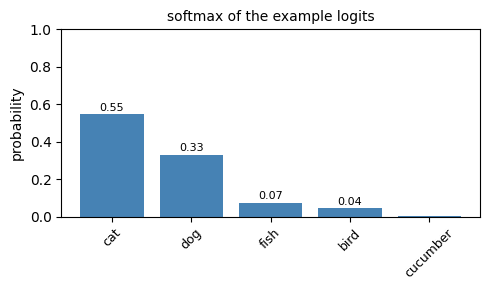

In [16]:
example_tokens = ['cat', 'dog', 'fish', 'bird', 'cucumber']
example_logits = np.array([3.0, 2.5, 1.0, 0.5, -2.0])

probs = softmax(example_logits)
print(f'logits: {example_logits}')
print(f'probs:  {probs.round(4)}')
print(f'sum:    {probs.sum():.6f}')

def plot_distribution(probs, tokens, title=None, ax=None, color='steelblue'):
    """Bar chart of a probability distribution. ax=None creates its own figure."""
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(5, 3))
    ax.bar(range(len(probs)), probs, color=color)
    ax.set_xticks(range(len(probs)))
    ax.set_xticklabels(tokens, rotation=45, fontsize=9)
    ax.set_ylabel('probability')
    ax.set_ylim(0, 1)
    if title:
        ax.set_title(title, fontsize=10)
    for i, p_val in enumerate(probs):
        if p_val > 0.01:
            ax.text(i, p_val + 0.02, f'{p_val:.2f}', ha='center', fontsize=8)
    if own_fig:
        plt.tight_layout()
        return fig
    return None

plot_distribution(probs, example_tokens, title='softmax of the example logits')
plt.show()

### 1.4 Temperature scaling

The first knob on top of softmax: **temperature**. Divide the logits by a positive scalar $T$ before applying softmax:

$$\text{softmax}_T(x)_i \;=\; \frac{e^{x_i / T}}{\sum_j e^{x_j / T}}.$$

Three regimes:

- **$T < 1$ — sharper.** Dividing by a number less than 1 *amplifies* the gaps between logits. The exponential then turns those bigger gaps into even bigger probability ratios. The distribution becomes peaked: high-logit tokens absorb almost all the mass. Useful when you want the model to commit to its best guess.
- **$T = 1$ — identity.** Standard softmax.
- **$T > 1$ — flatter.** Dividing by a number greater than 1 *shrinks* the gaps. Logits move closer together, and softmax responds with a more uniform output. Useful when you want diverse, creative samples.

Two limit cases worth remembering:

- $T \to 0^+$: $\text{argmax}$ — the distribution becomes one-hot on the top logit (greedy decoding).
- $T \to \infty$: uniform over the vocabulary — every token equally likely.

This is the lever language-model interfaces expose as the "temperature" slider. Low temperature = stick with the safe bet; high temperature = explore.

**Your turn:** Implement `softmax_with_temperature`. It should be a one-liner that divides by `temperature` and calls `softmax`.

In [17]:
def softmax_with_temperature(logits, temperature):
    """Softmax with temperature scaling: softmax(logits / temperature).

    Args:
        logits: 1-D array of raw scores.
        temperature: positive scalar. T=1 reproduces standard softmax,
            T<1 sharpens, T>1 flattens.

    Returns:
        Probability distribution (same shape as logits, sums to 1).

    Example:
        >>> softmax_with_temperature(np.array([1.0, 2.0]), 1.0).round(3)
        array([0.269, 0.731])
        >>> softmax_with_temperature(np.array([1.0, 2.0]), 0.1).round(3)  # very peaked
        array([0.   , 1.   ])
    """
    # TODO: divide logits by temperature, then apply softmax
    return softmax(logits/temperature)

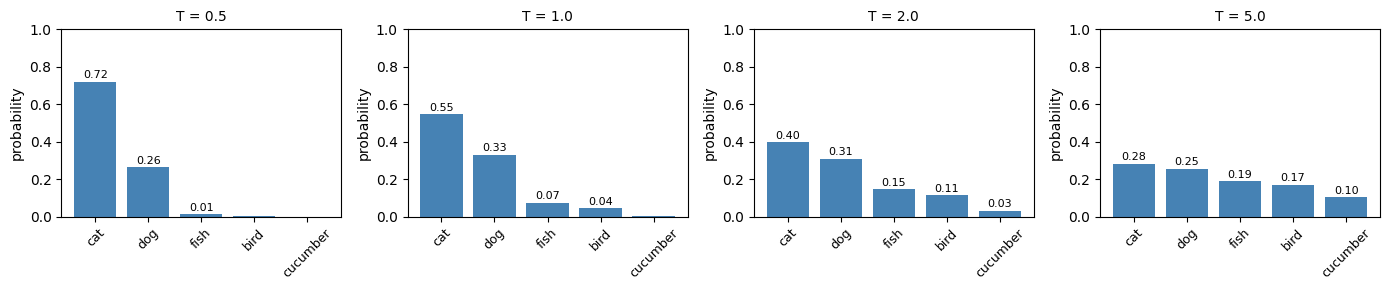

softmax_with_temperature verified.


In [18]:
# --- TEST: softmax_with_temperature ---

# T=1 should match plain softmax
assert np.allclose(
    softmax_with_temperature(np.array([1.0, 2.0, 3.0]), 1.0),
    softmax(np.array([1.0, 2.0, 3.0])),
), 'T=1 should equal softmax'

# Very low T should be argmax-like (one-hot on the top logit)
peaked = softmax_with_temperature(np.array([1.0, 2.0, 3.0]), 0.01)
assert peaked.argmax() == 2 and peaked.max() > 0.99, 'low T should be argmax-like'

# Very high T should be ~uniform
flat = softmax_with_temperature(np.array([1.0, 2.0, 3.0]), 100.0)
assert np.allclose(flat, [1/3, 1/3, 1/3], atol=0.02), 'high T should be uniform'

# Visualise four temperatures on the same logits
temperatures = [0.5, 1.0, 2.0, 5.0]
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, T_ in zip(axes, temperatures):
    p_T = softmax_with_temperature(example_logits, T_)
    plot_distribution(p_T, example_tokens, title=f'T = {T_}', ax=ax)
plt.tight_layout()
plt.show()

print('softmax_with_temperature verified.')

### 1.5 Top-k filtering

The second knob: **top-k**. After softmax, keep only the $k$ most-likely tokens, set the rest to zero, and renormalise so the survivors sum to 1.

**Why it matters.** Language models assign small but non-zero probability to many implausible tokens — the long tail. Even at $T = 1$, sampling from the full distribution will occasionally pick something silly. Top-k cuts the tail off entirely.

**The tradeoff.**

- $k = 1$ — greedy decoding (argmax). Same output every time, no randomness.
- $k = 5$ to $k = 50$ — typical practical range. Diverse but coherent.
- $k = $ vocabulary size — no truncation, full distribution.

Top-k is a **fixed cutoff** — it always keeps exactly $k$ tokens regardless of whether the distribution is peaked or flat. That limitation is what top-p (section 1.5) addresses.

**Your turn:** Implement `top_k_filter`. The cleanest way: find the $k$-th largest probability as a threshold, zero out anything below it, then renormalise.

In [27]:
def top_k_filter(probs, k):
    """Keep the k highest-probability entries; redistribute mass to sum to 1.

    Args:
        probs: 1-D probability distribution (sums to 1).
        k: number of entries to keep.

    Returns:
        New array, same shape, with at most k nonzero entries summing to 1.

    Example:
        >>> p = np.array([0.5, 0.3, 0.1, 0.1])
        >>> top_k_filter(p, k=2).round(3)
        array([0.625, 0.375, 0.   , 0.   ])
    """
    # TODO:
    # 1) find the k-th largest probability as a threshold
    # 2) zero out anything below that threshold
    # 3) renormalize so the survivors sum to 1
    # Hint: np.sort(probs)[-k] gives the k-th largest value.
    threshold = np.sort(probs)[-k]
    print(threshold)
    filtered_probs = np.where(probs >= threshold, probs, 0.0)
    print(filtered_probs)
    return filtered_probs / np.sum(filtered_probs)



0.3
[0.5 0.3 0.  0. ]
0.5
[0.5 0.  0.  0. ]
0.5462424589138729
[0.54624246 0.         0.         0.         0.        ]
0.33131279896808236
[0.54624246 0.3313128  0.         0.         0.        ]
0.07392587789297277
[0.54624246 0.3313128  0.07392588 0.         0.        ]
0.003680552736811796
[0.54624246 0.3313128  0.07392588 0.04483831 0.00368055]


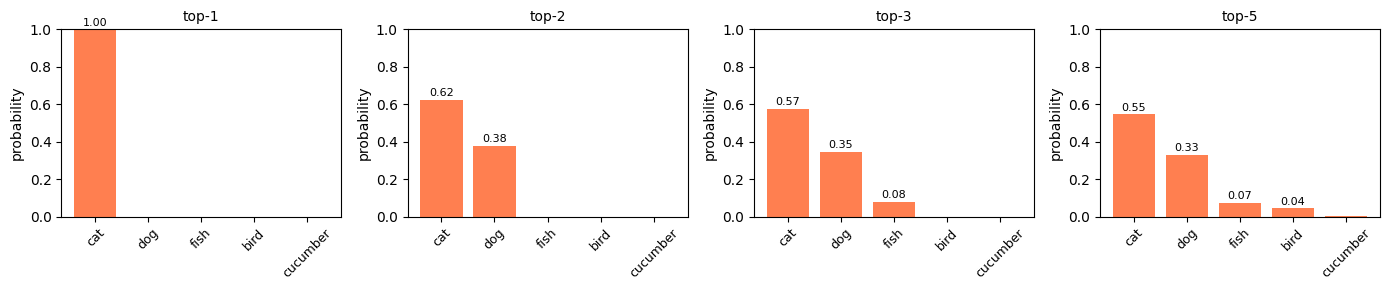

top_k_filter verified.


In [28]:
# --- TEST: top_k_filter ---

# Docstring example
p = np.array([0.5, 0.3, 0.1, 0.1])
f2 = top_k_filter(p, k=2)
assert np.allclose(f2, [0.625, 0.375, 0.0, 0.0]), f'top-2 wrong: {f2}'

# k=1 should be one-hot on the argmax
f1 = top_k_filter(p, k=1)
assert np.allclose(f1, [1.0, 0.0, 0.0, 0.0]), 'top-1 should be one-hot'

# Result is always a valid distribution
assert np.isclose(f2.sum(), 1.0) and (f2 >= 0).all()

# Visualise four cutoffs on the example distribution
probs_softmax = softmax(example_logits)
ks = [1, 2, 3, 5]
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, k_ in zip(axes, ks):
    p_k = top_k_filter(probs_softmax, k_)
    plot_distribution(p_k, example_tokens, title=f'top-{k_}', ax=ax, color='coral')
plt.tight_layout()
plt.show()

print('top_k_filter verified.')

### 1.6 Top-p (nucleus) filtering

The third knob: **top-p**, also called **nucleus sampling**. Keep the *smallest* set of tokens whose **cumulative** probability is at least $p$, then renormalise.

**Why it matters.** Top-k is a fixed cutoff and ignores the actual shape of the distribution. Sometimes 2 tokens already cover 95% of the mass; sometimes you need 30. Top-k either over-truncates the first case or under-truncates the second.

Top-p adapts. Pick a probability budget — typically $p = 0.9$ or $p = 0.95$ — and the algorithm keeps just enough tokens to cover that budget. The size of the kept set changes at every step depending on how peaked the distribution is.

**Algorithm:**

1. Sort probabilities in descending order.
2. Compute the cumulative sum along the sorted axis.
3. Find the smallest prefix whose cumulative sum is $\ge p$.
4. Keep those tokens, zero the rest, renormalise.

**Edge cases:**

- $p \to 0$: keep only the top-1.
- $p = 1$: keep the entire distribution unchanged.

**Your turn:** Implement `top_p_filter`. The hint cells below show the NumPy primitives that make this a five-line function.

In [54]:
def top_p_filter(probs, p):
    """Nucleus sampling: keep the smallest set of tokens with cumulative
    probability >= p, then renormalise.

    Args:
        probs: 1-D probability distribution (sums to 1).
        p: cumulative probability threshold in (0, 1].

    Returns:
        New array with mass on the nucleus, summing to 1.

    Example:
        >>> top_p_filter(np.array([0.5, 0.3, 0.15, 0.05]), 0.7).round(3)
        array([0.625, 0.375, 0.   , 0.   ])
    """
    # TODO:
    # 1) get the indices that sort probs in descending order
    # 2) compute the cumulative sum of the sorted probabilities
    # 3) find the cutoff index — smallest prefix where cumsum >= p
    # 4) keep those indices, zero the rest, renormalise
    # Hints:
    #   np.argsort(probs)[::-1]    — indices in descending order
    #   np.cumsum(sorted_probs)    — running totals
    #   np.searchsorted(cumsum, p) — first index where cumsum >= p
    print(probs)
    sorted_indices = np.argsort(probs)[::-1]
    sorted_probs = probs[sorted_indices]

    cumsum = np.cumsum(sorted_probs)
    print(cumsum)

    cutoff = np.searchsorted(cumsum,p)+1
    print(cutoff)

    filtered_probs = np.zeros_like(probs)
    top_indices = sorted_indices[:cutoff]
    filtered_probs[top_indices] = probs[top_indices]

    return filtered_probs / np.sum(filtered_probs)



[0.5  0.3  0.15 0.05]
[0.5  0.8  0.95 1.  ]
2
[0.5  0.3  0.15 0.05]
[0.5  0.8  0.95 1.  ]
4
[0.5  0.3  0.15 0.05]
[0.5  0.8  0.95 1.  ]
1
[0.54624246 0.3313128  0.07392588 0.04483831 0.00368055]
[0.54624246 0.87755526 0.95148114 0.99631945 1.        ]
1
[0.54624246 0.3313128  0.07392588 0.04483831 0.00368055]
[0.54624246 0.87755526 0.95148114 0.99631945 1.        ]
2
[0.54624246 0.3313128  0.07392588 0.04483831 0.00368055]
[0.54624246 0.87755526 0.95148114 0.99631945 1.        ]
3
[0.54624246 0.3313128  0.07392588 0.04483831 0.00368055]
[0.54624246 0.87755526 0.95148114 0.99631945 1.        ]
5


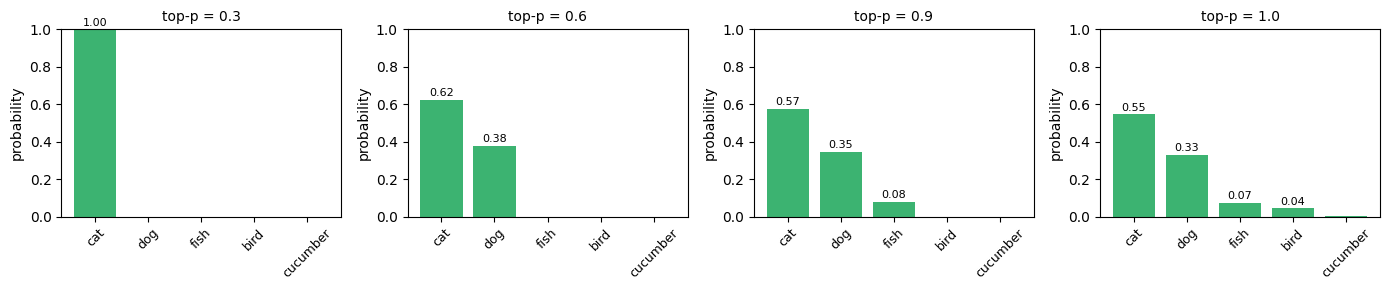

top_p_filter verified.


In [55]:
# --- TEST: top_p_filter ---

# Docstring example: 0.5 + 0.3 = 0.8 >= 0.7, so keep top 2 and renormalise
p_test = np.array([0.5, 0.3, 0.15, 0.05])
f_07 = top_p_filter(p_test, 0.7)
assert np.allclose(f_07, [0.625, 0.375, 0.0, 0.0]), f'p=0.7 wrong: {f_07}'

# p=1 should keep everything (full distribution survives)
f_1 = top_p_filter(p_test, 1.0)
assert np.allclose(f_1, p_test), 'p=1 should keep everything'

# Very small p should reduce to top-1
f_small = top_p_filter(p_test, 0.01)
assert np.allclose(f_small, [1.0, 0.0, 0.0, 0.0]), 'tiny p should be one-hot'

# Result is always a valid distribution
assert np.isclose(f_07.sum(), 1.0) and (f_07 >= 0).all()

# Visualise four budgets on the example distribution
probs_softmax = softmax(example_logits)
ps = [0.3, 0.6, 0.9, 1.0]
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, p_ in zip(axes, ps):
    p_filt = top_p_filter(probs_softmax, p_)
    plot_distribution(p_filt, example_tokens, title=f'top-p = {p_}', ax=ax, color='mediumseagreen')
plt.tight_layout()
plt.show()

print('top_p_filter verified.')

### 1.7 `attention(Q, K, V)` — build it from the lecture formula

This is the heart of the notebook. The lecture's one formula:

$$\operatorname{Attention}(Q, K, V) = \operatorname{softmax}\!\left(\frac{Q K^\top}{\sqrt{d_k}}\right) V$$

Notice the signature takes **Q, K, V directly** — already-projected queries, keys, and values, one row per token. The projection $Q = X W_Q$ is the "price of admission" the lecture mentions (§7.5): it happens *before* this formula and is the only part with learned weights. Keeping it outside lets `attention()` *be* the formula above — no weights, no bias, nothing the lecture didn't cover.

We build it in three small, separately-tested pieces:

1. `scaled_scores(Q, K)` — the $Q K^\top / \sqrt{d_k}$ part (you practised `Q @ K.T` in the warm-up).
2. `build_causal_mask(T)` — the upper-triangular $-\infty$ mask that makes attention causal.
3. `attention(Q, K, V, mask=False)` — assemble pieces 1 and 2 with `softmax`, then the `· V` weighted sum.

**Your turn (step 1/3):** Implement `scaled_scores`. Same `Q @ K.T` as the warm-up, now divided by $\sqrt{d_k}$, where $d_k$ is the per-token width of `Q` (its last-axis size). The lecture (§7.4) explains why we scale: without it the dot products grow like $\sqrt{d_k}$ and saturate the softmax.

In [56]:
def scaled_scores(Q, K):
    """Scaled dot-product scores: (Q @ K.T) / sqrt(d_k).

    Args:
        Q, K: (T, d_k) arrays of queries and keys (one row per token).

    Returns:
        (T, T) array of scaled scores; entry (i, j) is (Q[i] . K[j]) / sqrt(d_k).

    Example:
        >>> Q = np.array([[2.0, 0.0], [0.0, 2.0]])
        >>> K = np.array([[1.0, 0.0], [0.0, 1.0]])
        >>> scaled_scores(Q, K).round(4).tolist()   # d_k = 2, divide by sqrt(2)
        [[1.4142, 0.0], [0.0, 1.4142]]
    """
    # TODO:
    #   1) d_k = size of the last axis of Q  (Q.shape[-1])
    #   2) return (Q @ K.T) / np.sqrt(d_k)
    d_k = Q.shape[-1]
    return (Q@K.T) / np.sqrt(d_k)

In [57]:
# --- TEST: scaled_scores ---
Q_s = np.array([[2.0, 0.0], [0.0, 2.0]])
K_s = np.array([[1.0, 0.0], [0.0, 1.0]])
S_s = scaled_scores(Q_s, K_s)
assert S_s.shape == (2, 2), f'shape wrong: {S_s.shape}'
assert np.allclose(S_s, np.eye(2) * np.sqrt(2)), f'values wrong: {S_s}'

# Must divide by sqrt(d_k): with d_k=16 the raw dot product is scaled down by 4
rng_s = np.random.default_rng(3)
Q4, K4 = rng_s.normal(size=(3, 16)), rng_s.normal(size=(3, 16))
assert np.allclose(scaled_scores(Q4, K4), (Q4 @ K4.T) / np.sqrt(16))

print('scaled_scores verified.')

scaled_scores verified.


**Your turn (step 2/3):** Implement `build_causal_mask`. It returns a `(T, T)` matrix of `0`s with `-inf` strictly above the diagonal. Added to the scores before softmax, those `-inf` entries become `0` after `exp`, so each query attends only to itself and earlier positions (the lecture's causal mask, §8.2).

The one new primitive is **`np.triu_indices(T, k=1)`** — it returns the *(row, column)* index pairs strictly above the main diagonal of a `T × T` matrix:

- `k=0` → diagonal and above
- `k=1` → strictly above the diagonal (the diagonal itself stays at 0, so a query can attend to itself)
- `k=2` → strictly above the first super-diagonal

For `T = 4`, `np.triu_indices(4, k=1)` → `(array([0, 0, 0, 1, 1, 2]), array([1, 2, 3, 2, 3, 3]))` — exactly the entries where `j > i`. Write `-inf` into those positions of a zero matrix.

In [61]:
def build_causal_mask(T):
    """Additive causal mask: a (T, T) array, 0 on/below the diagonal, -inf above.

    Adding this to attention scores before softmax sends every "future" entry
    (column j > row i) to exactly 0 after the exp, so each query attends only to
    itself and earlier positions.

    Args:
        T: sequence length.

    Returns:
        (T, T) float array with 0 on and below the diagonal, -inf strictly above.

    Example:
        >>> build_causal_mask(3).tolist()
        [[0.0, -inf, -inf], [0.0, 0.0, -inf], [0.0, 0.0, 0.0]]
    """
    # TODO:
    #   1) start from a (T, T) array of zeros: np.zeros((T, T))
    #   2) set the strictly-above-diagonal entries to -np.inf using
    #      np.triu_indices(T, k=1)
    z_array_t = np.zeros((T,T))
    z_array_t[np.triu_indices(T, k=1)] = -np.inf
    return z_array_t

In [62]:
# --- TEST: build_causal_mask ---
M3 = build_causal_mask(3)
assert M3.shape == (3, 3)
assert np.array_equal(np.tril(M3), np.zeros((3, 3))), 'lower triangle + diagonal must be 0'
assert np.isneginf(M3[np.triu_indices(3, k=1)]).all(), 'strictly-above-diagonal must be -inf'

# After softmax the mask alone gives a lower-triangular, row-normalised pattern
A = softmax(M3, axis=-1)
assert np.allclose(np.triu(A, k=1), 0), 'future positions must be 0 after softmax'
assert np.allclose(A.sum(axis=-1), 1), 'each row must still sum to 1'

print('build_causal_mask verified.')

build_causal_mask verified.


**Your turn (step 3/3):** Assemble `attention(Q, K, V, mask=False)` from the two pieces you just built. The recipe is the lecture formula, top to bottom:

1. `scores = scaled_scores(Q, K)`
2. if `mask` is `True`, add `build_causal_mask(T)` (with `T` = the number of rows of `scores`)
3. `weights = softmax(scores, axis=-1)` — each row becomes a distribution over keys
4. return `weights @ V` (the output, one row per token) **and** `weights` (so we can plot the pattern)

In [63]:
def attention(Q, K, V, mask=False):
    """Scaled dot-product attention: softmax(Q K^T / sqrt(d_k)) @ V.

    Q, K, V are already-projected (T, d_k) tensors — one row per token. The
    projection that produces them (Q = X @ W_Q, ...) happens *before* this call.

    Args:
        Q, K, V: (T, d_k) arrays.
        mask: if True, apply a causal mask so each query attends only to itself
            and earlier positions.

    Returns:
        Tuple (output, weights). output is (T, d_k); weights is (T, T) and each
        row sums to 1.
    """
    # 1) scores = scaled_scores(Q, K)
    # 2) if mask: scores = scores + build_causal_mask(scores.shape[0])
    # 3) weights = softmax(scores, axis=-1)
    # 4) return weights @ V, weights

    scores = scaled_scores(Q, K)

    if mask:
        scores = scores + build_causal_mask(scores.shape[0])

    weights = softmax(scores, axis=-1)

    return weights @ V, weights

In [64]:
# --- TEST: attention ---
rng_a = np.random.default_rng(0)
Qa, Ka, Va = (rng_a.normal(size=(4, 8)) for _ in range(3))

out_open, w_open = attention(Qa, Ka, Va, mask=False)
out_causal, w_causal = attention(Qa, Ka, Va, mask=True)

# Shapes
assert out_open.shape == (4, 8) and w_open.shape == (4, 4), 'wrong output/weight shapes'

# Every attention row is a probability distribution
assert np.allclose(w_open.sum(axis=-1), 1) and (w_open >= 0).all()
assert np.allclose(w_causal.sum(axis=-1), 1)

# Causal: no weight on future positions; the first query attends only to itself
assert np.allclose(np.triu(w_causal, k=1), 0), 'causal mask leaked future weight'
assert np.isclose(w_causal[0, 0], 1.0), 'first query should attend only to itself'

# Output is a weighted average of value rows -> first causal output == first value row
assert np.allclose(out_causal[0], Va[0])

print('attention verified.')

attention verified.


### 1.8 `show_attention_scores()` — a reusable plot helper

We package the attention heatmap as a function so we can call it many times: once for the no-mask demo, once for the causal demo, and 12 times for the per-head distilgpt2 grid in Part 2.

The `ax=None` plumbing matters — when called without an `ax`, the function creates its own figure with a colorbar (good for one-off plots); when called with an `ax`, it draws on the provided axis (good for a grid of subplots) and skips the colorbar.

Cell value text is overlaid only when `T <= 6` so the function stays readable on the dragon-drinks toy without cluttering the 12-head grid later.

In [65]:
def show_attention_scores(A, tokens, title=None, ax=None):
    """Heatmap of an attention matrix A. Rows = queries, cols = keys.

    Args:
        A: (T, T) attention weights (rows sum to 1).
        tokens: list of T token strings used as row/column labels.
        title: optional plot title.
        ax: if provided, draw on this matplotlib axis (no colorbar). Otherwise
            create a new figure with a colorbar and return it.

    Returns:
        The Figure if a new one was created, else the image artist.
    """
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(4.5, 3.5))
    im = ax.imshow(A, cmap='Blues', aspect='auto', vmin=0, vmax=1)
    T = len(tokens)
    ax.set_xticks(range(T))
    ax.set_xticklabels(tokens, rotation=45, fontsize=8)
    ax.set_yticks(range(T))
    ax.set_yticklabels(tokens, fontsize=8)
    ax.set_xlabel('key (attended to)')
    ax.set_ylabel('query (attending from)')
    if title:
        ax.set_title(title)
    if T <= 6:
        for i in range(T):
            for j in range(T):
                colour = 'white' if A[i, j] > 0.5 else 'black'
                ax.text(j, i, f'{A[i, j]:.2f}', ha='center', va='center', fontsize=8, color=colour)
    if own_fig:
        plt.colorbar(im, ax=ax, label='weight')
        plt.tight_layout()
        return fig
    return im

### 1.9 Demo — compare masked vs unmasked on a 3-token toy

A minimal setup to exercise `attention()` end to end. Vocab `V=10`, embedding dim `d=6`, sequence `<BOS> dragon drinks` → token ids `(0, 5, 6)`. We draw a random embedding matrix `E` of shape `(V, d)`, look up the three token rows to form `X` of shape `(T=3, d=6)`, and use random `(d, d)` Q/K/V projection matrices. Single-head.

First we **project** `X` into queries, keys, and values (`Q = X @ W_Q`, and likewise for `K`, `V`) — the step that happens before the formula — then we call `attention(Q, K, V)` twice: once with `mask=False` (full self-attention, every token attends to every token) and once with `mask=True` (causal: each query can only look at itself and the past). Then `show_attention_scores()` plots both side by side so the difference is obvious.

no mask  — row sums: [1. 1. 1.]
causal   — row sums: [1. 1. 1.]
causal upper triangle max: 0.000e+00  (should be 0)


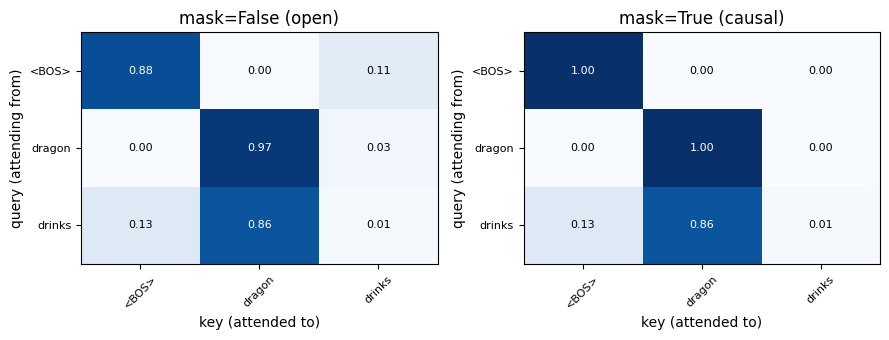

In [66]:
# Dragon-drinks toy: 3 tokens, 6-dim embeddings
V, d_toy = 10, 6
token_ids = np.array([0, 5, 6])               # <BOS> dragon drinks
tokens_toy = ['<BOS>', 'dragon', 'drinks']

E = rng.normal(size=(V, d_toy))
X_toy = E[token_ids]                          # (3, 6)

rng_attn = np.random.default_rng(0)
W_Q_toy = rng_attn.normal(size=(d_toy, d_toy))
W_K_toy = rng_attn.normal(size=(d_toy, d_toy))
W_V_toy = rng_attn.normal(size=(d_toy, d_toy))

# Project the toy embeddings into Q, K, V (the "price of admission" — this step
# happens before attention(), which now takes Q, K, V directly)
Q_toy = X_toy @ W_Q_toy
K_toy = X_toy @ W_K_toy
V_toy = X_toy @ W_V_toy

# Two calls — same Q/K/V, only the mask flag differs
_, A_open = attention(Q_toy, K_toy, V_toy, mask=False)
_, A_causal = attention(Q_toy, K_toy, V_toy, mask=True)

print(f'no mask  — row sums: {A_open.sum(axis=1).round(6)}')
print(f'causal   — row sums: {A_causal.sum(axis=1).round(6)}')
print(f'causal upper triangle max: {np.triu(A_causal, k=1).max():.3e}  (should be 0)')

# Plot both side by side using the reusable helper
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
show_attention_scores(A_open, tokens_toy, title='mask=False (open)', ax=axes[0])
show_attention_scores(A_causal, tokens_toy, title='mask=True (causal)', ax=axes[1])
plt.tight_layout()
plt.show()

### 1.10 Multi-head attention as a loop over single-head calls

Multi-head attention is **many small attentions on different subspaces of the embedding**. With `n_head` heads and head dim `d_head = d / n_head`, head `h` works on the columns `[h * d_head : (h + 1) * d_head]` of the projected `Q`, `K`, `V`. Each head runs the full `attention(Q, K, V)` you just built on its own slice; afterwards we concatenate the per-head outputs along the feature axis and apply one output projection `W_O` — the lecture's $Z = \operatorname{Concat}(Z^{(1)}, \dots, Z^{(H)})\, W_O$ (§9.1).

We express this literally as a loop that calls `attention()` once per head. The function you just built does the real work; multi-head is just bookkeeping — slice, loop, concatenate, project. **No bias appears here**: exactly like single-head `attention(Q, K, V)`, the projections (and any biases the real model carries) live entirely outside, in the projection step. We build it in two pieces:

1. `head_slice(M, h, n_head)` — grab head `h`'s columns of a `(T, d)` tensor (the column-range slicing from the warm-up).
2. `multi_head_attention(Q, K, V, W_O, n_head, mask=False)` — loop over heads, concatenate, project.

**Your turn (step 1/2):** Implement `head_slice`. Given a `(T, d)` tensor and a head index `h`, return just that head's `d_head = d / n_head` columns. Same column-range slicing as the warm-up, with the start/stop computed from `h`.

In [ ]:
def head_slice(M, h, n_head):
    """Return the columns of M (shape (T, d)) that belong to head h.

    With d_head = d // n_head, head h owns columns [h*d_head : (h+1)*d_head].

    Args:
        M: (T, d) tensor (a projected Q, K, or V).
        h: head index, 0 <= h < n_head.
        n_head: total number of heads (d must be divisible by n_head).

    Returns:
        (T, d_head) slice — head h's columns of M.

    Example:
        >>> M = np.arange(12).reshape(2, 6)        # 2 tokens, d=6
        >>> head_slice(M, 0, n_head=3).tolist()    # d_head = 2
        [[0, 1], [6, 7]]
        >>> head_slice(M, 2, n_head=3).tolist()
        [[4, 5], [10, 11]]
    """
    # TODO:
    #   1) d_head = M.shape[-1] // n_head
    #   2) return columns [h*d_head : (h+1)*d_head]  ->  M[:, h*d_head:(h+1)*d_head]
    pass

In [ ]:
# --- TEST: head_slice ---
M = np.arange(12).reshape(2, 6)        # 2 tokens, d=6, n_head=3 -> d_head=2
assert head_slice(M, 0, 3).tolist() == [[0, 1], [6, 7]], 'head 0 wrong'
assert head_slice(M, 1, 3).tolist() == [[2, 3], [8, 9]], 'head 1 wrong'
assert head_slice(M, 2, 3).tolist() == [[4, 5], [10, 11]], 'head 2 wrong'

# Each head is d_head wide, and concatenating all heads rebuilds M
d_head = M.shape[-1] // 3
pieces = [head_slice(M, h, 3) for h in range(3)]
assert all(p.shape == (2, d_head) for p in pieces)
assert np.array_equal(np.concatenate(pieces, axis=-1), M)

print('head_slice verified.')

**Your turn (step 2/2):** Assemble `multi_head_attention`. `Q`, `K`, `V` are the full `(T, d)` projected tensors. For each head: slice all three with `head_slice`, run `attention()` on the slices, and collect both the output and the weights. Then `np.concatenate` the per-head outputs along the last axis and project once with `W_O`. Return the `(T, d)` output and the stacked per-head weights `(n_head, T, T)`.

In [ ]:
def multi_head_attention(Q, K, V, W_O, n_head, mask=False):
    """Multi-head attention as a loop over single-head attention() calls.

    Q, K, V are full (T, d) projected tensors. Each head h runs attention() on
    its own d_head-wide column slice; the per-head outputs are concatenated and
    projected by W_O. No bias here — projections (and the real model's biases)
    happen before/after this function.

    Args:
        Q, K, V: (T, d) projected tensors.
        W_O: (d, d) output projection.
        n_head: number of heads. d must be divisible by n_head.
        mask: if True, each head's attention is causal.

    Returns:
        Tuple (output, per_head_weights). output is (T, d); per_head_weights
        is (n_head, T, T).
    """
    # TODO:
    #   1) for each head h in range(n_head):
    #        out_h, w_h = attention(head_slice(Q, h, n_head),
    #                               head_slice(K, h, n_head),
    #                               head_slice(V, h, n_head), mask=mask)
    #        collect out_h and w_h into two lists
    #   2) concat outputs along the last axis: np.concatenate(head_outs, axis=-1)
    #   3) project: out = concat @ W_O
    #   4) return out, np.stack(head_weights)
    pass

In [ ]:
# --- TEST: multi_head_attention ---
rng_m = np.random.default_rng(2)
T_m, d_m, n_head_m = 4, 6, 2           # d_head = 3
Qm, Km, Vm = (rng_m.normal(size=(T_m, d_m)) for _ in range(3))
W_O_m = rng_m.normal(size=(d_m, d_m))

out_m, w_m = multi_head_attention(Qm, Km, Vm, W_O_m, n_head=n_head_m, mask=True)

# Shapes: output matches input width; one (T, T) weight matrix per head
assert out_m.shape == (T_m, d_m), f'output shape {out_m.shape}, expected {(T_m, d_m)}'
assert w_m.shape == (n_head_m, T_m, T_m), f'weights shape {w_m.shape}'

# Each head's rows are valid distributions and respect the causal mask
assert np.allclose(w_m.sum(axis=-1), 1), 'each head row must sum to 1'
for h in range(n_head_m):
    assert np.allclose(np.triu(w_m[h], k=1), 0), f'head {h} leaked future weight'

# Equivalent to running attention() per head by hand, then concat @ W_O
outs = [attention(head_slice(Qm, h, n_head_m),
                  head_slice(Km, h, n_head_m),
                  head_slice(Vm, h, n_head_m), mask=True)[0]
        for h in range(n_head_m)]
assert np.allclose(np.concatenate(outs, axis=-1) @ W_O_m, out_m)

print('multi_head_attention verified.')

### 1.11 Multi-head sanity check on the toy

Two heads (`n_head = 2`, `d_head = 3`) on the dragon-drinks toy. We reuse the `Q_toy / K_toy / V_toy` we projected in section 1.9 and just add an output projection `W_O_toy`. Output shape should match the input `(3, 6)`, and the per-head weights should be `(2, 3, 3)`.

In [ ]:
rng_mh = np.random.default_rng(1)
W_O_toy = rng_mh.normal(size=(d_toy, d_toy))

out_mh, weights_mh = multi_head_attention(
    Q_toy, K_toy, V_toy, W_O_toy, n_head=2, mask=True,
)
print(f'multi-head output shape:  {out_mh.shape}  (expect ({X_toy.shape[0]}, {d_toy}))')
print(f'per-head weights shape:   {weights_mh.shape}  (expect (2, 3, 3))')
print(f'each head row sums to 1?  {np.allclose(weights_mh.sum(axis=-1), 1)}')

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
show_attention_scores(weights_mh[0], tokens_toy, title='head 0 (causal)', ax=axes[0])
show_attention_scores(weights_mh[1], tokens_toy, title='head 1 (causal)', ax=axes[1])
plt.tight_layout()
plt.show()

## Part 2 — Apply the primitives to real `distilgpt2`

Now we point the same `attention()`, `multi_head_attention()`, and `show_attention_scores()` at a real, trained 6-layer 12-head transformer (`distilgpt2`, ~82M parameters, GPT-2 tokenizer).

**Scope.** We verify the **attention sub-layer** (`ln_1` → `c_attn` → multi-head attention → `c_proj`) of **layer 3** against HuggingFace's forward pass. We do not reproduce the full layer (residuals + LN + FFN) — to do so we'd have to redo every prior layer. Instead we use HF's `output_hidden_states=True` to get the residual-stream input *into* layer 3 for free.

**The Conv1D gotcha.** HuggingFace GPT-2 stores attention projections in layers it calls `Conv1D` — which, despite the name, are *linear* layers (`x @ W + b`), not convolutions (a GPT-2 legacy). The weight shape is `[in, out]`, opposite of `nn.Linear`. The forward call is `x @ W + b` — *no* transpose. Get this wrong and shapes still match, but values are nonsense.

**Outcome.** By the end of Part 2 you will:
- Know that the function you wrote in Part 1 is the actual computation real LLMs run, modulo bookkeeping.
- Have visualised the 12 attention heads of one layer on a real sentence and identified which heads do what.
- Have generated a few next-token candidates with temperature + top-k sampling.

### 2.1 Load `distilgpt2`

In [ ]:
MODEL_NAME = 'distilgpt2'
tokenizer = GPT2TokenizerFast.from_pretrained(MODEL_NAME)
model = GPT2LMHeadModel.from_pretrained(MODEL_NAME, attn_implementation='eager')
model.eval()

cfg = model.config
d = cfg.hidden_size
n_head = cfg.num_attention_heads
n_layer = cfg.num_hidden_layers
d_head = d // n_head
ln_eps = cfg.layer_norm_epsilon

print(f'Model:    {MODEL_NAME}')
print(f'Layers:   {n_layer}')
print(f'd:        {d}')
print(f'n_head:   {n_head}')
print(f'd_head:   {d_head}  (= d / n_head)')
print(f'ln eps:   {ln_eps}')
print(f'params:   {sum(p.numel() for p in model.parameters()):,}')

### 2.2 Tokenize the sentence

We use `"The cat sat on the mat"` — the lecture's running cat example, lengthened slightly so the heatmaps in section 2.7 show some structure. GPT-2's tokenizer encodes leading-space-included tokens (`" cat"`, not `"cat"`).

In [ ]:
SENTENCE = 'The cat sat on the mat'
encoded = tokenizer(SENTENCE, return_tensors='pt')
input_ids = encoded.input_ids        # (1, T)
T = input_ids.shape[-1]
tokens = [tokenizer.decode([tid]) for tid in input_ids[0].tolist()]

print(f'Input: {SENTENCE!r}')
print(f'T = {T} tokens')
for i, (tid, tok) in enumerate(zip(input_ids[0].tolist(), tokens)):
    print(f'  pos {i}: id={tid:>5d}  token={tok!r}')

### 2.3 One forward pass — capture hidden states + the layer-3 attention output

Two things we need from HF:

1. The **input to layer 3's attention** — that is `hidden_states[3]` (output of layer 2 = input to layer 3). HF returns this for free with `output_hidden_states=True`.
2. The **output of layer 3's attention sub-layer** — what HF computed, so we can compare. Captured via a forward hook on `model.transformer.h[3].attn`.

We also grab `output_attentions=True` so we can compare per-head attention weights in section 2.7.

Layer index choice: layer 3 (out of 6) — middle of the network, where heads tend to specialise.

In [ ]:
LAYER = 3   # 0-indexed; distilgpt2 has layers 0..5

captured = {}
def hook(module, inputs, outputs):
    # GPT2Attention returns (attn_output, present_key_value, attn_weights_or_None)
    captured['hf_attn_output'] = outputs[0].detach().cpu().numpy()

handle = model.transformer.h[LAYER].attn.register_forward_hook(hook)
with torch.no_grad():
    out = model(**encoded, output_hidden_states=True, output_attentions=True)
handle.remove()

hidden_in = out.hidden_states[LAYER].detach().cpu().numpy()      # (1, T, d) — input to layer LAYER
hf_attn_out = captured['hf_attn_output']                          # (1, T, d) — what we want to reproduce
hf_attn_weights = out.attentions[LAYER].detach().cpu().numpy()    # (1, n_head, T, T)

print(f'hidden_states[{LAYER}] shape: {hidden_in.shape}  — input to layer {LAYER}')
print(f'hf attn output shape:        {hf_attn_out.shape}  — captured by hook')
print(f'hf attn weights shape:       {hf_attn_weights.shape}')

### 2.4 Extract layer-3 weights as NumPy

Everything we need to reproduce the attention sub-layer:
- `ln_1.weight`, `ln_1.bias` — pre-attention LayerNorm.
- `attn.c_attn.weight`, `attn.c_attn.bias` — packs Q, K, V projections into one `(d, 3d)` matrix.
- `attn.c_proj.weight`, `attn.c_proj.bias` — output projection (the `W_O` from the lecture).

All weights are float32. We keep them as NumPy from here on.

In [ ]:
block = model.transformer.h[LAYER]

ln1_w = block.ln_1.weight.detach().cpu().numpy()
ln1_b = block.ln_1.bias.detach().cpu().numpy()

c_attn_w = block.attn.c_attn.weight.detach().cpu().numpy()
c_attn_b = block.attn.c_attn.bias.detach().cpu().numpy()

c_proj_w = block.attn.c_proj.weight.detach().cpu().numpy()
c_proj_b = block.attn.c_proj.bias.detach().cpu().numpy()

for name, arr in [('ln1.weight', ln1_w), ('ln1.bias', ln1_b),
                  ('c_attn.weight', c_attn_w), ('c_attn.bias', c_attn_b),
                  ('c_proj.weight', c_proj_w), ('c_proj.bias', c_proj_b)]:
    print(f'  {name:18s} shape {str(arr.shape):>14s}  dtype {arr.dtype}')

### 2.5 The HF Conv1D gotcha

`c_attn` and `c_proj` are HuggingFace `Conv1D` layers (legacy from the original GPT-2 codebase). **Despite the name, a `Conv1D` here is a plain linear layer — `x @ W + b` — not a convolution.** It just differs from `nn.Linear` in two ways:

- **Weight shape:** `c_attn.weight.shape == (d, 3d)`. With `nn.Linear` it would be `(3d, d)`.
- **Forward:** `output = input @ weight + bias`. With `nn.Linear` it would be `input @ weight.T + bias` (note the transpose).

Get this wrong and your shapes still match, but the numbers are wrong. The cell below is a sanity check — use it as a template the next time you reach into a HuggingFace model.

In [ ]:
# Sanity check: with the right convention the shape works out cleanly
h_for_check = hidden_in[0]                                       # (T, d) — drop batch
qkv_check = h_for_check @ c_attn_w + c_attn_b                    # (T, 3d)
print(f'c_attn applied as x @ W + b → shape {qkv_check.shape}  (expect {(T, 3*d)})')
assert qkv_check.shape == (T, 3 * d)

# What goes wrong with the wrong convention?
try:
    wrong = h_for_check @ c_attn_w.T + c_attn_b
    print(f'  with the wrong .T: shape {wrong.shape}  ← would fail because (d) ≠ (3d) on the inner axis')
except Exception as e:
    print(f'  with the wrong .T: {type(e).__name__}: {e}')

### Your turn: wrap the HF linear projection as a function

Section 2.5 showed that HuggingFace's `Conv1D` is a linear layer that applies as `x @ weight + bias` — *not* `x @ weight.T + bias` like `nn.Linear`. Wrap that convention as a small helper named `hf_linear` (the `Conv1D` name is HF's; the operation is just a linear projection). We reuse it in section 2.6 to apply the real `c_attn` projection.

In [ ]:
def hf_linear(x, weight, bias):
    """Apply a HuggingFace Conv1D-style linear projection: x @ weight + bias.

    HF calls this layer `Conv1D` for GPT-2 legacy reasons, but it is a linear
    layer, not a convolution. Note the `(in, out)` weight layout, opposite of
    `nn.Linear` which uses `(out, in)`.

    Args:
        x: (..., in) input array
        weight: (in, out) — HF Conv1D weight tensor as NumPy
        bias: (out,) bias vector

    Returns:
        (..., out) output

    Example:
        >>> x = np.array([[1.0, 2.0]])
        >>> W = np.array([[1.0, 0.0, 1.0], [0.0, 1.0, 1.0]])  # shape (2, 3)
        >>> b = np.array([0.1, 0.2, 0.3])
        >>> hf_linear(x, W, b)
        array([[1.1, 2.2, 3.3]])
    """
    # TODO: implement using @ and +
    pass

In [ ]:
# --- TEST: hf_linear ---

# Docstring example
x_demo = np.array([[1.0, 2.0]])
W_demo = np.array([[1.0, 0.0, 1.0], [0.0, 1.0, 1.0]])
b_demo = np.array([0.1, 0.2, 0.3])
out_demo = hf_linear(x_demo, W_demo, b_demo)
assert np.allclose(out_demo, [[1.1, 2.2, 3.3]]), f'docstring example failed: got {out_demo}'

# Apply to the real layer-3 c_attn — should match the raw x @ W + b from section 2.5
qkv_via_helper = hf_linear(h_for_check, c_attn_w, c_attn_b)
assert np.allclose(qkv_via_helper, qkv_check, atol=1e-12), 'should match raw x @ W + b'

# Output shape: last axis of weight
assert qkv_via_helper.shape == (T, 3 * d), f'shape should be ({T}, {3*d})'

print('hf_linear verified.')

### 2.6 Build the attention sub-layer on top of our primitives

We add one more given helper — `layernorm` — then reuse `hf_linear` and a new "Your turn" `split_qkv` to project the input, and finally wrap everything into `numpy_attention_block` on top of the `multi_head_attention` you built in Part 1.

**LayerNorm recap.** For each token row independently, LayerNorm subtracts the mean, divides by the standard deviation, then scales by a learned `gamma` and shifts by a learned `beta`:

$$\text{LN}(x)_i \;=\; \gamma \,\frac{x_i - \mu}{\sqrt{\sigma^2 + \epsilon}} \;+\; \beta, \qquad \mu = \tfrac{1}{d}\sum_j x_j, \quad \sigma^2 = \tfrac{1}{d}\sum_j (x_j - \mu)^2.$$

The `eps` term prevents division by zero on near-constant rows. The implementation below uses `axis=-1, keepdims=True` so the per-row statistics broadcast cleanly back against `x`.

In [ ]:
def layernorm(x, gamma, beta, eps):
    """Per-row LayerNorm matching PyTorch (population variance)."""
    mu = x.mean(axis=-1, keepdims=True)
    var = x.var(axis=-1, keepdims=True)
    return gamma * (x - mu) / np.sqrt(var + eps) + beta

### Your turn: split a `(*, 3d)` tensor into Q, K, V

HuggingFace's `c_attn` packs Q, K, V contiguously along the last axis: the first `d` columns are Q, the next `d` are K, the last `d` are V. Wrap that split as a reusable function — it's the column-range slicing from the warm-up, three times.

It works on **any** tensor whose last axis has size `3d`. In `numpy_attention_block` below, we use it on the projected `qkv` of shape `(T, 3d)` to recover three `(T, d)` tensors Q, K, V. (The test cell also splits the `c_attn` *weight* matrix `(d, 3d)` into `W_Q, W_K, W_V`, to show the same function handles either.)

In [ ]:
def split_qkv(qkv, d):
    """Split a tensor whose last axis has size 3*d into three Q, K, V tensors.

    Args:
        qkv: shape (..., 3 * d). For the projected output it's (T, 3 * d);
            for the c_attn weight matrix it's (d, 3 * d).
        d: hidden dimension.

    Returns:
        Tuple (Q, K, V), each with the last axis trimmed to size d.

    Example:
        >>> qkv = np.arange(12).reshape(2, 6)
        >>> Q_, K_, V_ = split_qkv(qkv, d=2)
        >>> Q_.tolist()
        [[0, 1], [6, 7]]
        >>> V_.tolist()
        [[4, 5], [10, 11]]
    """
    # TODO: slice along the last axis to get three (..., d) views
    pass

In [ ]:
# --- TEST: split_qkv ---

# Docstring example
qkv_t = np.arange(12).reshape(2, 6)
Q_t, K_t, V_t = split_qkv(qkv_t, d=2)
assert Q_t.tolist() == [[0, 1], [6, 7]], f'Q wrong: {Q_t.tolist()}'
assert K_t.tolist() == [[2, 3], [8, 9]], f'K wrong: {K_t.tolist()}'
assert V_t.tolist() == [[4, 5], [10, 11]], f'V wrong: {V_t.tolist()}'

# Apply to real c_attn weight — should give three (d, d) blocks
W_Q_real, W_K_real, W_V_real = split_qkv(c_attn_w, d)
assert W_Q_real.shape == (d, d) and W_K_real.shape == (d, d) and W_V_real.shape == (d, d)

# Apply to projected qkv — should give three (T, d) blocks matching c_attn_w columns
qkv_real = hf_linear(h_for_check, c_attn_w, c_attn_b)
Q_real, K_real, V_real = split_qkv(qkv_real, d)
assert np.allclose(Q_real, h_for_check @ W_Q_real + c_attn_b[:d]), 'Q mismatch'
assert np.allclose(K_real, h_for_check @ W_K_real + c_attn_b[d:2*d]), 'K mismatch'
assert np.allclose(V_real, h_for_check @ W_V_real + c_attn_b[2*d:]), 'V mismatch'

# Round-trip: concatenating back should reproduce qkv
recombined = np.concatenate([Q_real, K_real, V_real], axis=-1)
assert np.allclose(recombined, qkv_real), 'concat(Q, K, V) should reproduce qkv'

print('split_qkv verified.')

### Your turn: package the attention block as one function

Wrap the entire NumPy attention sub-layer into a single function: LayerNorm → project with `hf_linear` → split into Q, K, V → multi-head causal attention → add the output-projection bias. This is the primitive you'd reach for to apply your code to a different layer or a different model.

You reuse `layernorm`, `hf_linear`, `split_qkv`, and `multi_head_attention`.

The pipeline — note that **bias appears only here**, in the projection steps, never inside `attention` or `multi_head_attention`:

1. `h_ln = layernorm(hidden, ln_w, ln_b, eps)`
2. Project with bias: `qkv = hf_linear(h_ln, c_attn_w, c_attn_b)` → shape `(T, 3d)`.
3. Split: `Q, K, V = split_qkv(qkv, d)` → each `(T, d)`.
4. `out, weights = multi_head_attention(Q, K, V, c_proj_w, n_head, mask=True)`.
5. Add the output-projection bias: `out = out + c_proj_b`.
6. Return `(out, weights)`.

In [ ]:
def numpy_attention_block(
    hidden,
    ln_w, ln_b,
    c_attn_w, c_attn_b,
    c_proj_w, c_proj_b,
    n_head,
    eps=1e-5,
):
    """Run the GPT-2 attention sub-layer in pure NumPy on top of our primitives.

    Args:
        hidden: (T, d) — residual-stream input to the layer (e.g. hidden_states[L] from HF)
        ln_w, ln_b: (d,) each — pre-attention LayerNorm parameters
        c_attn_w, c_attn_b: Q/K/V projection weight (d, 3d) and bias (3d,)
        c_proj_w, c_proj_b: output projection weight (d, d) and bias (d,)
        n_head: number of attention heads (d must be divisible by n_head)
        eps: LayerNorm epsilon (1e-5 in GPT-2 / distilgpt2)

    Returns:
        Tuple (output, weights). output is (T, d) — what HF returns from
        h[layer].attn before the residual is added. weights is (n_head, T, T).
    """
    # TODO: assemble the pipeline. Bias appears ONLY in the projection steps
    # (hf_linear and the final + c_proj_b) — never inside attention/MHA.
    #   1) d = hidden.shape[-1]
    #   2) h_ln = layernorm(hidden, ln_w, ln_b, eps)
    #   3) qkv = hf_linear(h_ln, c_attn_w, c_attn_b)        # (T, 3d)
    #   4) Q, K, V = split_qkv(qkv, d)
    #   5) out, weights = multi_head_attention(Q, K, V, c_proj_w, n_head, mask=True)
    #   6) out = out + c_proj_b
    #   7) return out, weights
    pass

In [ ]:
# --- TEST: numpy_attention_block ---

h = hidden_in[0]                                    # (T, d) — drop batch
hf = hf_attn_out[0]                                 # (T, d) — HF ground truth

custom, weights = numpy_attention_block(
    h, ln1_w, ln1_b, c_attn_w, c_attn_b, c_proj_w, c_proj_b,
    n_head=n_head, eps=ln_eps,
)

max_diff = float(np.max(np.abs(custom - hf)))
print(f'max |custom - hf| via numpy_attention_block = {max_diff:.3e}')

assert custom.shape == hf.shape, f'shape mismatch: {custom.shape} vs {hf.shape}'
assert weights.shape == (n_head, T, T), f'weights shape: {weights.shape}'
assert np.allclose(custom, hf, atol=1e-4), f'numpy_attention_block does not match HF: {max_diff}'

print('numpy_attention_block reproduces the HuggingFace attention sub-layer.')

### 2.7 Verify against HuggingFace

If the math (and the Conv1D convention) is right, our pure-NumPy output should match the HF model's attention sub-layer output to float32 precision. We allow `atol=1e-5` for accumulated rounding.

In [ ]:
max_abs_diff = float(np.max(np.abs(custom - hf)))
rel_err = max_abs_diff / float(np.max(np.abs(hf)))

print(f'max |custom - hf| = {max_abs_diff:.3e}')
print(f'relative max diff = {rel_err:.3e}')
print(f'np.allclose(atol=1e-5): {np.allclose(custom, hf, atol=1e-5)}')
print(f'np.allclose(atol=1e-4): {np.allclose(custom, hf, atol=1e-4)}')

assert np.allclose(custom, hf, atol=1e-4), 'attention block mismatch'
print('\n  PASS — your NumPy attention reproduces the HuggingFace model to float-precision.')

### 2.8 Visualise all 12 attention heads

Now the fun part — what does each head actually look at? We plot the per-head attention matrix `weights[h]` for layer 3 on the cat-sat-on-the-mat sentence. Heads often specialise: previous-token heads (sub-diagonal stripe), copy heads, BOS-attractor heads, syntactic heads.

We also confirm our per-head weights match HuggingFace's reported attention weights for this layer.

In [ ]:
# Cross-check: do our per-head attention weights match HF's?
hf_A = hf_attn_weights[0]                  # (n_head, T, T)
max_A_diff = float(np.max(np.abs(weights - hf_A)))
print(f'per-head attention weights vs HF: max diff = {max_A_diff:.3e}')
assert np.allclose(weights, hf_A, atol=1e-5), 'per-head attention weight mismatch'

# Plot 12 heads in a 3x4 grid, reusing show_attention_scores
clean_tokens = [t.strip() for t in tokens]
fig, axes = plt.subplots(3, 4, figsize=(13, 9))
for h_ix in range(n_head):
    ax = axes[h_ix // 4, h_ix % 4]
    show_attention_scores(weights[h_ix], clean_tokens, title=f'head {h_ix}', ax=ax)
fig.suptitle(f'distilgpt2 layer {LAYER} — attention patterns per head on "{SENTENCE}"',
             fontsize=13, y=1.0)
plt.tight_layout()
plt.show()

### 2.9 Bonus — sampling next tokens (reusing our primitives)

We have not built the FFN or the residual stream by hand — but HF has, and the final hidden state is sitting in `out.hidden_states[-1]`. Apply `model.lm_head` (which is weight-tied to the input embedding `wte`) to get logits over the 50 257-token vocabulary, then sample.

Sampling reuses the functions we built in sections 1.4–1.6: `softmax_with_temperature`, `top_k_filter`, `top_p_filter`. Those tiny exercises on a 5-token toy now apply directly to a real LM.

This closes the lecture's full forward-pass story: tokens → embed → blocks → head → next-token distribution → sample.

In [ ]:
# Final hidden state (output of last layer) — for the LAST token, since we want next-token logits
h_final = out.hidden_states[-1][0, -1].detach().cpu().numpy()    # (d,)
wte_w = model.transformer.wte.weight.detach().cpu().numpy()      # (V, d)

# Logits = h_final @ wte_w.T (weight-tied output head)
logits = h_final @ wte_w.T                                       # (V,)
print(f'logits shape: {logits.shape}  (V = vocab size)')

def sample_next_token(logits, temperature=0.8, top_k=None, top_p=None,
                      n_samples=5, seed=0):
    """Compose the three primitives we built earlier."""
    probs = softmax_with_temperature(logits, temperature)
    if top_k is not None:
        probs = top_k_filter(probs, top_k)
    if top_p is not None:
        probs = top_p_filter(probs, top_p)
    rng_local = np.random.default_rng(seed)
    samples = rng_local.choice(len(probs), size=n_samples, p=probs)
    return samples, probs

samples, probs = sample_next_token(logits, temperature=0.8, top_k=10, n_samples=8)

# Show the survivors of the top-k filter
top_ids = np.argsort(probs)[-10:][::-1]
print(f'\nTop-10 candidates after "{SENTENCE}" (T=0.8, top_k=10):')
for tid in top_ids:
    if probs[tid] > 0:
        print(f'  p={probs[tid]:.3f}  id={tid:>5d}  token={tokenizer.decode([int(tid)])!r}')

print(f'\n8 samples drawn:')
for tid in samples:
    print(f'  {SENTENCE} +  {tokenizer.decode([int(tid)])!r}')

## 3. Self-check + AI Diary

Answer each prompt below in the markdown cell underneath.

### 1. The built-in mask

Section 1.7 builds the causal mask in `build_causal_mask(T)` using `np.triu_indices(T, k=1)`, and `attention()` adds it to the scores. In one sentence, why is `k=1` the right argument (rather than `k=0` or `k=2`)? What would change in the attention pattern if you used `k=0` instead?

*Your answer here*

### 2. The Conv1D gotcha

Section 2.5 showed `c_attn.weight.shape == (d, 3d)` and the forward call is `x @ W + b`. If HuggingFace had used `nn.Linear` instead, what would the weight shape and forward call look like? In one sentence, why is this difference worth knowing about even outside this notebook?

*Your answer here*

### 3. Pick a head and describe it

Look at the 12 heatmaps in section 2.8. Pick **one** head whose pattern caught your eye and describe it in 2–3 sentences: which positions does each query attend to, and what does that pattern remind you of (previous-token, BOS-attractor, copy, syntactic, ...)?

*Your answer here*

### 4. Why we did not reproduce the full layer

We verified the **attention sub-layer** of layer 3 against HuggingFace, not the entire layer. To reproduce the *full* output of layer 3 to float-precision, what additional pieces would you need to implement (in order)? List them — you don't have to write the code.

*Your answer here*

### 5. Weight tying

Section 2.9 used `wte.weight.T` as the output projection. The lecture calls this *weight tying* and notes it saves `V · d` parameters compared to a separate `W_U`. For distilgpt2 (V ≈ 50 257, d = 768), how many parameters does weight tying save? Express the saving as a percentage of the model's total parameter count.

*Your answer here*

### 6. Temperature sweep

Re-run the sampling cell in section 2.9 with `temperature ∈ {0.3, 1.0, 2.0}`. Paste the top-10 distributions for each, and in 2–3 sentences explain what changed and why. Connect this to the lecture's discussion of greedy vs creative sampling.

*Your answer here*

### 7. Loop vs vectorised multi-head

Our `multi_head_attention()` loops over heads and calls `attention()` once per head — 12 calls per forward pass at layer 3 of distilgpt2. A production implementation would instead reshape Q, K, V to shape `(n_head, T, d_head)` and run **one** batched matmul `Qh @ Kh.transpose(0, 2, 1)` over all heads at once. Which is easier to read, and which would you ship to production? Why?

*Your answer here*